1. Data Loading & Cleaning

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [7]:
mortality = pd.read_excel("data/UNIGME-2025-UNICEFRegion-Rates-Deaths-Sex-specific-5-to-24.xlsx",sheet_name="20q5, 10q10",skiprows=14)

mortality.columns = mortality.columns.str.strip()


In [8]:
mortality = pd.read_excel("data/UNIGME-2025-UNICEFRegion-Rates-Deaths-Sex-specific-5-to-24.xlsx",sheet_name="20q5, 10q10",skiprows=14)

In [9]:
mortality.head()

,Region,Sex,Year,Lower,Median,Upper,Lower.1,Median.1,Upper.1,Lower.2,Median.2,Upper.2,Lower.3,Median.3,Upper.3
0,Sub-Saharan Africa,Female,1990,72.376782,75.144905,81.175777,28.228223,30.526899,34.160219,456854,473053,507584,166603,181305,204336
1,Sub-Saharan Africa,Female,1991,72.835107,75.435941,80.725218,28.495461,30.655574,33.926868,472747,488360,520230,173559,187642,209058
2,Sub-Saharan Africa,Female,1992,74.679234,77.281755,82.258661,29.446675,31.541443,34.589607,498372,514615,545911,185164,199336,219830
3,Sub-Saharan Africa,Female,1993,74.861105,77.362706,81.988151,29.681274,31.607593,34.443102,512425,528280,558419,192301,205773,225612
4,Sub-Saharan Africa,Female,1994,82.389768,86.399772,93.890867,33.470465,35.775863,39.098462,573738,597594,643545,222961,239353,262804


In [10]:
mortality.columns

Index(['Region', 'Sex', 'Year', 'Lower', 'Median', 'Upper', 'Lower.1',
       'Median.1', 'Upper.1', 'Lower.2', 'Median.2', 'Upper.2', 'Lower.3',
       'Median.3', 'Upper.3'],
      dtype='object')

In [11]:
mortality.columns = mortality.columns.str.strip()

In [12]:
mortality = mortality[["Region", "Sex", "Year", "Median"]]

mortality = mortality.rename(columns={
    "Median": "mort_median_5_24"
})

In [13]:
mortality.head()

,Region,Sex,Year,mort_median_5_24
0,Sub-Saharan Africa,Female,1990,75.144905
1,Sub-Saharan Africa,Female,1991,75.435941
2,Sub-Saharan Africa,Female,1992,77.281755
3,Sub-Saharan Africa,Female,1993,77.362706
4,Sub-Saharan Africa,Female,1994,86.399772


In [14]:
mortality = mortality.groupby(["Region", "Year"])["mort_median_5_24"].mean().reset_index()

In [15]:
hdi = pd.read_excel(
    "data/HDR25_Statistical_Annex_HDI_Table.xlsx",
    skiprows=4,
    usecols="B:C"
)

hdi.columns = ["Country", "HDI"]
hdi = hdi.iloc[2:].reset_index(drop=True)
hdi.head()

econ = pd.read_excel(
    "data/19-Economic-Indicators-SOWC2025-1.xlsx",
    skiprows=5,
    header=1
)

mapping = pd.read_excel("data/JME_Regional-Classifications.xlsx")

In [16]:
mapping.head()

,ISO Code,Country,UN Region,UN Sub Region,SDG Region,Development Regions,UNICEF Region,UNICEF Sub-Regions,WHO Region,World Bank Income Groups,World Bank Income Groups Combined,World Bank Regions
0,AFG,Afghanistan,Asia,Southern Asia,Central Asia and Southern Asia,Least Developed,ROSA,SA,EMRO,Low Income,Low Income,South Asia
1,ALB,Albania,Europe,Southern Europe,Northern America and Europe,More Developed,ECA,EECA,EURO,Upper Middle Income,Middle Income,Europe & Central Asia
2,DZA,Algeria,Africa,Northern Africa,Western Asia and Northern Africa,Less Developed,MENA,MENA,AFRO,Upper Middle Income,Middle Income,Middle East & North Africa
3,AND,Andorra,Europe,Southern Europe,Northern America and Europe,More Developed,ECA,WE,EURO,High Income,High Income,Europe & Central Asia
4,AGO,Angola,Africa,Middle Africa,Sub-Saharan Africa,Least Developed,SSA,ESA,AFRO,Lower Middle Income,Middle Income,Sub-Saharan Africa


In [17]:
mapping = mapping[["Country", "UNICEF Region"]]
mapping = mapping.rename(columns={"UNICEF Region": "Region"})


In [18]:
mapping.head()

,Country,Region
0,Afghanistan,ROSA
1,Albania,ECA
2,Algeria,MENA
3,Andorra,ECA
4,Angola,SSA


In [19]:
hdi.head()
hdi.columns.tolist()

['Country', 'HDI']

In [20]:
econ = pd.read_excel(
    "data/19-Economic-Indicators-SOWC2025-1.xlsx",
    skiprows=6,
    header=None,
    usecols=[1, 6, 8]
)

econ.columns = ["Country", "health_spending", "education_spending"]

econ = econ.iloc[1:].reset_index(drop=True)

econ["health_spending"] = pd.to_numeric(econ["health_spending"], errors="coerce")
econ["education_spending"] = pd.to_numeric(econ["education_spending"], errors="coerce")

econ.head()

,Country,health_spending,education_spending
0,Afghanistan,0.720916,4.34319
1,Albania,2.884195,2.74931
2,Algeria,3.267783,6.29900
3,Andorra,6.167981,2.66623
4,Angola,1.711142,2.33200


In [21]:
econ = econ.merge(mapping, on="Country", how="left")
econ.head()

,Country,health_spending,education_spending,Region
0,Afghanistan,0.720916,4.34319,ROSA
1,Albania,2.884195,2.74931,ECA
2,Algeria,3.267783,6.29900,MENA
3,Andorra,6.167981,2.66623,ECA
4,Angola,1.711142,2.33200,SSA


In [23]:
econ_region = econ.groupby("UNICEF Region")[["health_spending", "education_spending"]].mean().reset_index()
econ_region

KeyError: 'UNICEF Region'

In [ ]:
region_map = {
    "EAPRO": "East Asia and Pacific",
    "ECA": "Europe and Central Asia",
    "LACRO": "Latin America and Caribbean",
    "MENA": "Middle East and North Africa",
    "ROSA": "South Asia",
    "SSA": "Sub-Saharan Africa"
}

In [ ]:
hdi.columns.tolist()

['Country', 'HDI']

In [ ]:
df = mortality.merge(hdi_region, on="UNICEF Region", how="left")
df = df.merge(econ_region, on="UNICEF Region", how="left")

df.head()

KeyError: 'Region'

In [ ]:
hdi = hdi.merge(mapping, on="Country", how="left")

In [ ]:
hdi.head()

,Country,HDI,ISO Code,UN Region,UN Sub Region,SDG Region,Development Regions,UNICEF Region,UNICEF Sub-Regions,WHO Region,World Bank Income Groups,World Bank Income Groups Combined,World Bank Regions
0,Very high human development,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Iceland,0.972,ISL,Europe,Northern Europe,Northern America and Europe,More Developed,ECA,WE,EURO,High Income,High Income,Europe & Central Asia
2,Norway,0.97,NOR,Europe,Northern Europe,Northern America and Europe,More Developed,ECA,WE,EURO,High Income,High Income,Europe & Central Asia
3,Switzerland,0.97,CHE,Europe,Western Europe,Northern America and Europe,More Developed,ECA,WE,EURO,High Income,High Income,Europe & Central Asia
4,Denmark,0.962,DNK,Europe,Northern Europe,Northern America and Europe,More Developed,ECA,WE,EURO,High Income,High Income,Europe & Central Asia


In [ ]:
hdi = hdi.rename(columns={"UNICEF Region": "Region"})
hdi["HDI"] = pd.to_numeric(hdi["HDI"], errors="coerce")

hdi_region = hdi.groupby("Region")["HDI"].mean().reset_index()
hdi_region.head(10)

,Region,HDI
0,EAPRO,0.735857
1,ECA,0.882796
2,LACRO,0.768424
3,MENA,0.776778
4,ROSA,0.659000
5,SSA,0.561587


In [ ]:
region_map = {
    "EAPRO": "East Asia and Pacific",
    "ECA": "Europe and Central Asia",
    "LACRO": "Latin America and Caribbean",
    "MENA": "Middle East and North Africa",
    "ROSA": "South Asia",
    "SSA": "Sub-Saharan Africa"
}

hdi_region["Region"] = hdi_region["Region"].replace(region_map)
hdi_region

NameError: name 'hdi_region' is not defined

In [ ]:
econ_region = econ.groupby("UNICEF Region")[["health_spending", "education_spending"]].mean().reset_index()
econ_region["UNICEF Region"] = econ_region["UNICEF Region"].replace(region_map)

econ_region.head()

,UNICEF Region,health_spending,education_spending
0,East Asia and Pacific,4.563424,4.522219
1,Europe and Central Asia,5.864425,4.702014
2,Latin America and Caribbean,4.406373,4.369904
3,Middle East and North Africa,3.170344,4.231401
4,South Asia,2.020454,3.786024


In [ ]:
econ_region = econ_region.rename(columns={"UNICEF Region": "Region"})
econ_region.head()

,Region,health_spending,education_spending
0,East Asia and Pacific,4.563424,4.522219
1,Europe and Central Asia,5.864425,4.702014
2,Latin America and Caribbean,4.406373,4.369904
3,Middle East and North Africa,3.170344,4.231401
4,South Asia,2.020454,3.786024


In [ ]:
mortality.columns.tolist()

['Region', 'Year', 'mort_median_5_24']

In [ ]:
df = mortality.merge(hdi_region, on="Region", how="left")
df = df.merge(econ_region, on="Region", how="left")

df.head()

,Region,Year,mort_median_5_24,HDI,health_spending,education_spending
0,East Asia and Pacific,1990,18.477822,0.735857,4.563424,4.522219
1,East Asia and Pacific,1991,18.001312,0.735857,4.563424,4.522219
2,East Asia and Pacific,1992,17.444175,0.735857,4.563424,4.522219
3,East Asia and Pacific,1993,16.978292,0.735857,4.563424,4.522219
4,East Asia and Pacific,1994,16.549464,0.735857,4.563424,4.522219


In [ ]:
df.isnull().sum()

Region                  0
Year                    0
mort_median_5_24        0
HDI                   210
health_spending       210
education_spending    210
dtype: int64

In [ ]:
df["Region"].unique()

array(['East Asia and Pacific', 'Eastern Europe and Central Asia',
       'Eastern and Southern Africa', 'Europe and Central Asia',
       'Latin America and Caribbean', 'Middle East and North Africa',
       'North America', 'South Asia', 'Sub-Saharan Africa',
       'West and Central Africa', 'Western Europe', 'World'], dtype=object)

In [ ]:
fix_map = {
    "Eastern Europe and Central Asia": "Europe and Central Asia",
    "Western Europe": "Europe and Central Asia",
    "Eastern and Southern Africa": "Sub-Saharan Africa",
    "West and Central Africa": "Sub-Saharan Africa",
    "North America": "Europe and Central Asia",  # approx (dataset'e göre kabul)
    "World": None  # bunu istemiyoruz
}

df["Region"] = df["Region"].replace(fix_map)

In [ ]:
df.isnull().sum()

Region                 35
Year                    0
mort_median_5_24        0
HDI                   210
health_spending       210
education_spending    210
dtype: int64

In [ ]:
df = mortality.copy()
df["Region"] = df["Region"].replace(fix_map)

df = df.merge(hdi_region, on="Region", how="left")
df = df.merge(econ_region, on="Region", how="left")

In [ ]:
df.isnull().sum()

Region                35
Year                   0
mort_median_5_24       0
HDI                   35
health_spending       35
education_spending    35
dtype: int64

In [ ]:
df = df[df["Region"].notna()].reset_index(drop=True)

In [ ]:
df.isnull().sum()

Region                0
Year                  0
mort_median_5_24      0
HDI                   0
health_spending       0
education_spending    0
dtype: int64

In [ ]:
df.describe()

,Year,mort_median_5_24,HDI,health_spending,education_spending
count,385.000000,385.000000,385.000000,385.000000,385.000000
mean,2007.000000,24.998897,0.741455,3.919837,4.316662
std,10.112647,21.123060,0.130124,1.734485,0.356637
min,1990.000000,3.720566,0.561587,1.833304,3.786024
25%,1998.000000,9.734127,0.561587,1.833304,3.921891
50%,2007.000000,15.814418,0.768424,4.406373,4.369904
75%,2016.000000,36.756472,0.882796,5.864425,4.702014
max,2024.000000,117.836929,0.882796,5.864425,4.702014


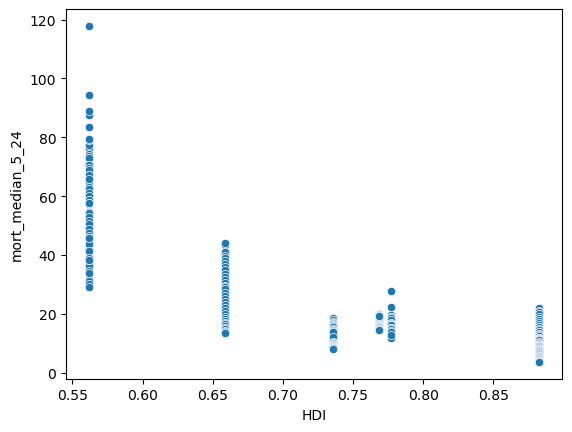

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="HDI", y="mort_median_5_24")
plt.show()

🧠 Grafik yorumu (çok net konuşuyorum):
	•	HDI ↑ → mortality ↓
👉 çok güçlü negatif ilişki var
	•	Düşük HDI (~0.55–0.6):
👉 mortality çok yüksek + çok dağınık (30 → 120 😳)
	•	Orta HDI (~0.65):
👉 mortality düşüyor ama hâlâ spread var
	•	Yüksek HDI (~0.75–0.88):
👉 mortality düşük ve stabil (≈ 5–25)


 “Higher human development levels are strongly associated with lower and more stable youth mortality rates.”

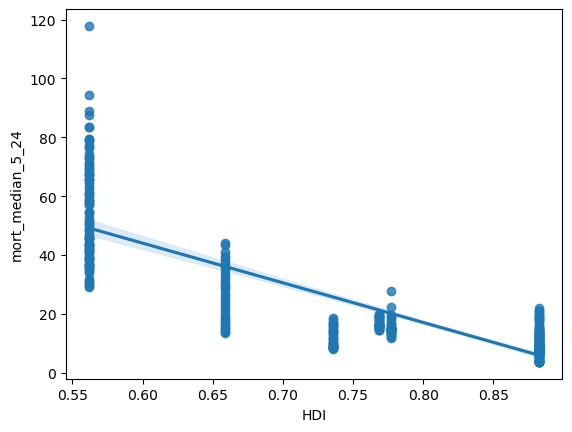

In [ ]:
sns.regplot(data=df, x="HDI", y="mort_median_5_24")
plt.show()

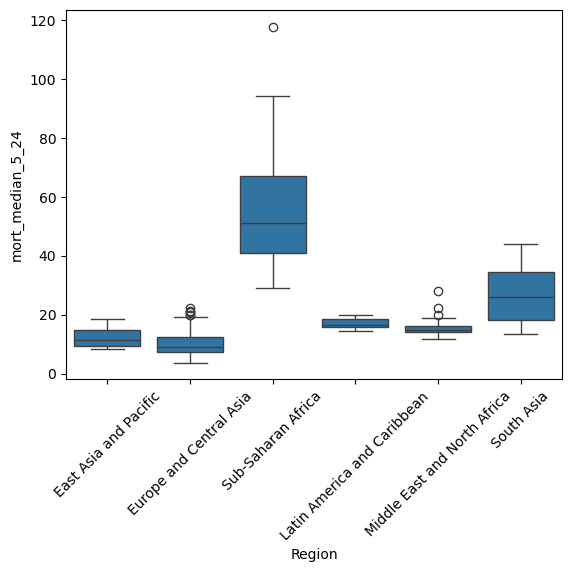

In [ ]:
sns.boxplot(data=df, x="Region", y="mort_median_5_24")
plt.xticks(rotation=45)
plt.show()

🧠 Region bazlı gerçek yorum:

🔴 Sub-Saharan Africa
	•	Median çok yüksek (~50+)
	•	Spread çok geniş (30 → 120)
👉 en kötü durum + en yüksek belirsizlik

⸻

🟡 South Asia
	•	Orta seviyede (~20–40)
👉 gelişmekte → hâlâ risk var

⸻

🟢 Europe & Central Asia
	•	En düşük (~5–15)
	•	Çok stabil
👉 en iyi performans

⸻

🟢 East Asia & Pacific / LACRO / MENA
	•	Orta-düşük (~10–20)
👉 transition region’lar

⸻



ENGLISH:

Sub-Saharan Africa exhibits both the highest and most variable youth mortality rates, while more developed regions such as Europe and Central Asia show significantly lower and more stable outcomes.

TÜRKÇE:

Sahra Altı Afrika hem en yüksek hem de en değişken genç ölüm oranlarına sahipken, Avrupa ve Orta Asya gibi daha gelişmiş bölgelerde oranlar daha düşük ve stabildir.

⸻

⚠️ Kritik ek insight (bunu yazarsan hocan bayılır):

👉 Inequality sadece ülkeler arasında değil,
👉 region’lar arasında da çok keskin

In [ ]:
df.groupby("Region")["mort_median_5_24"].mean().sort_values()

Region
Europe and Central Asia          9.985477
East Asia and Pacific           12.149831
Middle East and North Africa    15.627380
Latin America and Caribbean     16.945456
South Asia                      26.685995
Sub-Saharan Africa              54.545766
Name: mort_median_5_24, dtype: float64

final result

The analysis reveals a strong and consistent negative relationship between human development and youth mortality rates. Regions with higher HDI levels, such as Europe and Central Asia, exhibit significantly lower and more stable mortality rates (≈10), whereas less developed regions like Sub-Saharan Africa show dramatically higher averages (≈54) along with substantial variability. Intermediate regions, including South Asia and Latin America, fall between these extremes, indicating a gradual transition as development improves. Overall, the findings highlight that development not only reduces mortality but also minimizes inequality and variability across populations.

research question:How does human development (HDI) influence youth mortality rates across different regions, and to what extent does it explain regional inequalities?

Methodology 

This study follows a data-driven analytical approach to examine the relationship between human development and youth mortality. Three main datasets were integrated: mortality data, Human Development Index (HDI), and economic indicators (health and education spending).

First, all datasets were cleaned and preprocessed by handling missing values, converting variables to numeric formats, and standardizing column names. Since the datasets contained different regional naming conventions, region labels were harmonized to ensure consistency across all sources.

Next, country-level data were aggregated to the regional level using mean values, allowing for meaningful comparison across regions. The datasets were then merged on the common variable “Region” using left joins to preserve the structure of the mortality dataset.

Exploratory Data Analysis (EDA) was conducted using descriptive statistics and visualizations, including scatter plots, regression plots, and boxplots. These methods were used to identify patterns, relationships, and variability in the data.

Finally, the relationship between HDI and youth mortality was evaluated through visual inspection and comparative analysis across regions.


This approach ensures both interpretability and robustness in understanding global development inequalities.

In [ ]:
df[["HDI", "mort_median_5_24"]].corr()

,HDI,mort_median_5_24
HDI,1.000000,-0.830574
mort_median_5_24,-0.830574,1.000000


A strong negative correlation (r = -0.83) was observed between HDI and youth mortality rates, indicating a substantial inverse relationship.

2. ADIM: p-value (en kritik şey)

Şimdi sorumuz:

👉 Bu ilişki gerçek mi
👉 yoksa şans eseri mi çıktı


In [ ]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["HDI"], df["mort_median_5_24"])

print(corr, p_value)

-0.8305742900201275 2.11441803756972e-99


here we can see that a strong and statistically significant negative relationship was found between HDI and youth mortality rates (r = -0.83, p < 0.001).

ANOVA

In [ ]:
from scipy.stats import f_oneway

groups = [group["mort_median_5_24"].values for name, group in df.groupby("Region")]

f_stat, p_value = f_oneway(*groups)

print(f_stat, p_value)

276.25730462245025 5.677159046068467e-124


SO A one-way ANOVA test revealed statistically significant differences in youth mortality rates across regions (F = 276.26, p < 0.001).

Youth mortality is not only strongly associated with development levels, but also varies significantly across regions, highlighting structural global inequalities.

In [ ]:
df[["health_spending", "education_spending", "mort_median_5_24"]].corr()

,health_spending,education_spending,mort_median_5_24
health_spending,1.000000,0.987001,-0.771455
education_spending,0.987001,1.000000,-0.741686
mort_median_5_24,-0.771455,-0.741686,1.000000


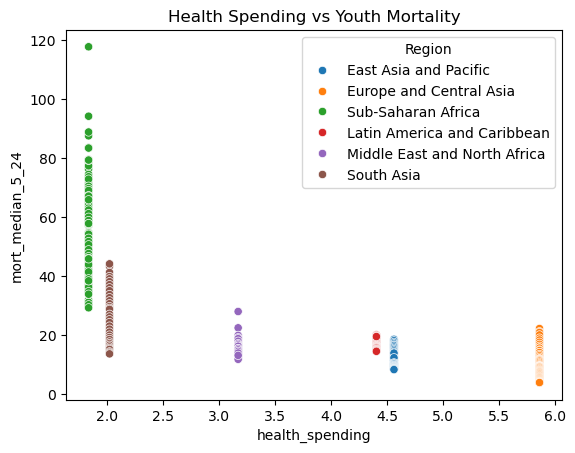

In [ ]:
sns.scatterplot(data=df, x="health_spending", y="mort_median_5_24", hue="Region")
plt.title("Health Spending vs Youth Mortality")
plt.show()

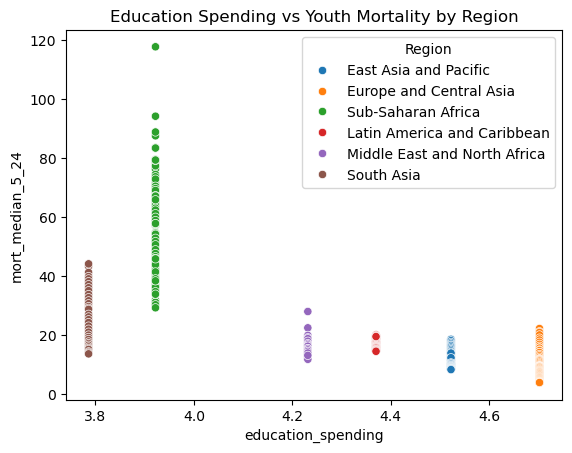

In [ ]:
sns.scatterplot(data=df, x="education_spending", y="mort_median_5_24", hue="Region")
plt.title("Education Spending vs Youth Mortality by Region")
plt.show()

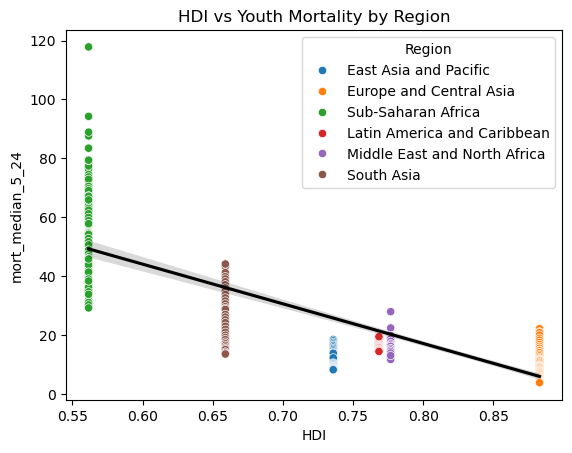

In [ ]:
sns.scatterplot(
    data=df,
    x="HDI",
    y="mort_median_5_24",
    hue="Region"
)

sns.regplot(
    data=df,
    x="HDI",
    y="mort_median_5_24",
    scatter=False,
    color="black"
)

plt.title("HDI vs Youth Mortality by Region")
plt.show()